# Online Learning Applications — Project
## Bidding on Multiple Advertising Campaigns under Budget Constraints

**Setting.** An agency bids in `N` parallel **first-price auctions** (one per
campaign). Each round `t = 1..T`: we choose a bid `b_i` from a discrete set
$\mathcal{B}$ for each campaign we enter; we win campaign `i` iff
$b_i \ge m_i$ (the highest competing bid), getting utility $v_i - b_i$ and
paying $b_i$. Global constraints:

- a total **budget** $B$ over the whole horizon;
- a **conflict graph**: non-compatible campaigns cannot be bid on in the same
  round (the set of campaigns entered each round must be an *independent set*).

**Notebook structure**

| Section | Content | Owner |
|---|---|---|
| 0 | Shared core: graph, agent/env interface, clairvoyant LP, runner, plots | Person 1 |
| 1 | Req. 1 — single campaign, stochastic: UCB1 & budgeted UCB | Person 2 |
| 2 | Req. 2 — multiple campaigns, stochastic: Combinatorial-UCB + budget | Person 3 |
| 3 | Req. 3 — best-of-both-worlds: primal-dual (full feedback) | Person 4 |
| 4 | Req. 4 — slightly non-stationary: SW / change-detector + comparison | Person 5 |

**The interface (do not change without telling everyone):**
```python
bids = agent.bid()          # {campaign: bid}, keys form an independent set
feedback = env.round(bids)  # {i: {"won", "m", "cost", "utility"}}
agent.update(feedback)      # "m" is None unless full_feedback=True (Req. 3)
```
Regret is always measured against `clairvoyant_series(...)`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations, product
from scipy.optimize import linprog

BIDS = np.round(np.arange(0.0, 1.01, 0.1), 2)   # the discrete bid set B
T = 1000
rng_global = np.random.default_rng(0)

---
# 0. Shared core (Person 1)

## 0.1 Conflict graph + independent-set oracle

`max_weight_independent_set` (brute force over the cached enumeration, fine
for $N \lesssim 15$) is the combinatorial oracle C-UCB calls every round.

In [2]:
from itertools import combinations


class ConflictGraph:
    def __init__(self, n_campaigns, edges=()):
        """
        Parameters
        ----------
        n_campaigns : int
        edges : iterable of (i, j) pairs, 0-indexed campaigns
        """
        self.n = n_campaigns
        self.adj = [set() for _ in range(n_campaigns)]
        for i, j in edges:
            if i == j:
                raise ValueError("self-loops not allowed")
            self.adj[i].add(j)
            self.adj[j].add(i)
        self._independent_sets = None

    @property
    def edges(self):
        return [(i, j) for i in range(self.n) for j in self.adj[i] if i < j]

    def is_independent(self, campaigns):
        campaigns = list(campaigns)
        for a, b in combinations(campaigns, 2):
            if b in self.adj[a]:
                return False
        return True

    def independent_sets(self, include_empty=True):
        """Enumerate ALL independent sets (cached). Fine for n <= ~15."""
        if self._independent_sets is None:
            sets = []
            for mask in range(1 << self.n):
                s = tuple(i for i in range(self.n) if mask >> i & 1)
                if self.is_independent(s):
                    sets.append(s)
            self._independent_sets = sets
        if include_empty:
            return list(self._independent_sets)
        return [s for s in self._independent_sets if s]

    def maximal_independent_sets(self):
        """Independent sets not contained in a larger one."""
        all_sets = [set(s) for s in self.independent_sets(include_empty=False)]
        return [tuple(sorted(s)) for s in all_sets
                if not any(s < t for t in all_sets)]

    def max_weight_independent_set(self, weights):
        """Return (best_set, best_value) maximizing sum of weights.

        `weights[i]` is the value of including campaign i (may be <= 0;
        campaigns with weight <= 0 are simply never worth including).
        Brute force over cached independent sets — the oracle used by
        Combinatorial-UCB.
        """
        best_set, best_val = (), 0.0
        for s in self.independent_sets():
            val = sum(weights[i] for i in s)
            if val > best_val:
                best_set, best_val = s, val
        return best_set, best_val

    @staticmethod
    def no_conflicts(n_campaigns):
        return ConflictGraph(n_campaigns, edges=())

    @staticmethod
    def cycle(n_campaigns):
        edges = [(i, (i + 1) % n_campaigns) for i in range(n_campaigns)]
        return ConflictGraph(n_campaigns, edges)

## 0.2 Agent base class

Subclass `Agent`, implement `bid()` and `update()` (always call
`super().update(feedback)`). Helpers: `self.remaining_budget`,
`self.pacing_rate` ($\rho_t$ = remaining budget / remaining rounds).

In [3]:
import numpy as np


class Agent:
    def __init__(self, n_campaigns, values, bids, budget, T,
                 graph=None, rng=None):
        """
        Parameters
        ----------
        n_campaigns : int
        values : array-like, len n_campaigns — value v_i of winning campaign i
        bids : array-like — the discrete bid set B (shared by all campaigns)
        budget : float — total budget for the whole horizon
        T : int — number of rounds
        graph : ConflictGraph or None (None = no conflicts)
        rng : np.random.Generator
        """
        self.n = n_campaigns
        self.values = np.asarray(values, dtype=float)
        self.bids = np.asarray(sorted(bids), dtype=float)
        self.budget = float(budget)
        self.T = int(T)
        self.graph = graph if graph is not None else ConflictGraph.no_conflicts(n_campaigns)
        self.rng = rng if rng is not None else np.random.default_rng()
        self.t = 0                      # rounds played
        self.spent = 0.0                # budget spent so far
        self._last_bids = {}

    # ---- to implement in subclasses -------------------------------------
    def bid(self):
        """Return {campaign: bid} for this round (keys = independent set)."""
        raise NotImplementedError

    def update(self, feedback):
        """Consume this round's feedback. Subclasses MUST call super().update."""
        self.t += 1
        self.spent += sum(f["cost"] for f in feedback.values())

    # ---- helpers ---------------------------------------------------------
    @property
    def remaining_budget(self):
        return max(self.budget - self.spent, 0.0)

    @property
    def pacing_rate(self):
        """Remaining budget per remaining round, rho_t."""
        remaining_rounds = max(self.T - self.t, 1)
        return self.remaining_budget / remaining_rounds

    def reset(self):
        self.t = 0
        self.spent = 0.0
        self._last_bids = {}


class RandomAgent(Agent):
    """Sanity-check baseline: random maximal independent set, random bids."""

    def bid(self):
        sets_ = self.graph.maximal_independent_sets() or [()]
        s = sets_[self.rng.integers(len(sets_))]
        out = {}
        afford = self.remaining_budget
        for i in s:
            b = float(self.rng.choice(self.bids))
            if b <= afford:
                out[i] = b
                afford -= b
        self._last_bids = out
        return out


class ConstantBidAgent(Agent):
    """Bids a fixed vector on a fixed independent set (useful for debugging
    and as the arms of hindsight comparisons)."""

    def __init__(self, *args, campaign_bids=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.campaign_bids = dict(campaign_bids or {})
        assert self.graph.is_independent(self.campaign_bids.keys())

    def bid(self):
        afford = self.remaining_budget
        out = {}
        for i, b in self.campaign_bids.items():
            if b <= afford:
                out[i] = b
                afford -= b
        return out

## 0.3 Environments

The base pre-draws the whole $m$ sequence at `reset(seed)` so every agent in a
comparison faces the **same** realized competing bids (paired trials, lower
variance). Then the four environments, one per requirement.

In [4]:
import numpy as np


class Environment:
    def __init__(self, n_campaigns, T, values, full_feedback=False, seed=None):
        self.n = n_campaigns
        self.T = int(T)
        self.values = np.asarray(values, dtype=float)
        self.full_feedback = full_feedback
        self.seed = seed
        self.reset(seed)

    # ---- to implement in subclasses -------------------------------------
    def sample_m(self, t, size=None):
        """Sample highest competing bids for round t.

        Returns array of shape (n,) if size is None, else (size, n).
        Used both to run the environment and (by baselines) to Monte-Carlo
        estimate win probabilities. Must use self.rng.
        """
        raise NotImplementedError

    # ---- shared machinery ------------------------------------------------
    def reset(self, seed=None):
        self.rng = np.random.default_rng(self.seed if seed is None else seed)
        self.t = 0
        self.history_m = np.zeros((self.T, self.n))
        # Pre-draw the whole sequence so every agent in a comparison faces
        # the SAME realized competing bids (paired comparisons, lower variance).
        for t in range(self.T):
            self.history_m[t] = self.sample_m(t)

    def round(self, bids):
        assert self.t < self.T, "horizon exhausted"
        m = self.history_m[self.t]
        feedback = {}
        for i, b in bids.items():
            won = bool(b >= m[i])
            feedback[i] = {
                "won": won,
                "m": float(m[i]) if self.full_feedback else None,
                "cost": float(b) if won else 0.0,
                "utility": float(self.values[i] - b) if won else 0.0,
            }
        self.t += 1
        return feedback

    def win_prob(self, i, b, t=0, n_samples=10_000):
        """Monte-Carlo P(m_i <= b) at round t — used by clairvoyants only."""
        rng_state = self.rng
        self.rng = np.random.default_rng(12345)   # fixed, independent stream
        samples = self.sample_m(t, size=n_samples)[:, i]
        self.rng = rng_state
        return float(np.mean(samples <= b))

In [5]:
import numpy as np


class SingleCampaignStochastic(Environment):
    """Requirement 1: one campaign, m_t ~ Beta(alpha, beta) i.i.d.

    Beta on [0, 1] matches a bid set in [0, 1]. Pick (alpha, beta) so the
    optimal bid is interior, e.g. (2, 4) -> mean 1/3.
    """

    def __init__(self, T, value=1.0, alpha=2.0, beta=4.0,
                 full_feedback=False, seed=None):
        self.alpha, self.beta = alpha, beta
        super().__init__(1, T, [value], full_feedback, seed)

    def sample_m(self, t, size=None):
        n = 1 if size is None else size
        out = self.rng.beta(self.alpha, self.beta, size=(n, self.n))
        return out[0] if size is None else out


class JointStochastic(Environment):
    """Requirement 2: N campaigns, correlated competing bids.

    Common-factor model:  m_i = clip(z + eps_i, 0, 1)
        z     ~ Beta(az, bz)          shared market level  (correlation)
        eps_i ~ Normal(mu_i, sigma_i)  campaign-specific offset
    Marginals differ across campaigns via (mu_i, sigma_i).
    """

    def __init__(self, n_campaigns, T, values,
                 az=2.0, bz=4.0, mu=None, sigma=None,
                 full_feedback=False, seed=None):
        self.az, self.bz = az, bz
        self.mu = np.zeros(n_campaigns) if mu is None else np.asarray(mu, float)
        self.sigma = (np.full(n_campaigns, 0.05) if sigma is None
                      else np.asarray(sigma, float))
        super().__init__(n_campaigns, T, values, full_feedback, seed)

    def sample_m(self, t, size=None):
        n = 1 if size is None else size
        z = self.rng.beta(self.az, self.bz, size=(n, 1))
        eps = self.rng.normal(self.mu, self.sigma, size=(n, self.n))
        out = np.clip(z + eps, 0.0, 1.0)
        return out[0] if size is None else out

In [6]:
import numpy as np


class HighlyNonStationary(Environment):
    """Requirement 3: distribution changes QUICKLY over time.

    The mean of each campaign's competing bid follows a fast sinusoid with
    campaign-specific phase, plus noise:

        mu_i(t) = center_i + amp_i * sin(2*pi*freq*t + phase_i)
        m_i,t   ~ clip( Normal(mu_i(t), noise), 0, 1 )

    With freq high (e.g. 10-20 full oscillations over the horizon) no fixed
    distribution fits — stochastic algorithms like (C-)UCB break here.
    """

    def __init__(self, n_campaigns, T, values,
                 center=0.4, amp=0.3, freq=15.0, noise=0.03,
                 full_feedback=True, seed=None):
        self.center = np.full(n_campaigns, center, float)
        self.amp = np.full(n_campaigns, amp, float)
        self.freq = freq
        self.noise = noise
        self._phase = None  # set in reset (needs rng)
        self._T = T
        super().__init__(n_campaigns, T, values, full_feedback, seed)

    def reset(self, seed=None):
        # phases drawn once per reset, before pre-drawing the sequence
        rng = np.random.default_rng(self.seed if seed is None else seed)
        self._phase = rng.uniform(0, 2 * np.pi, size=self.n)
        super().reset(seed)

    def mean_at(self, t):
        x = 2 * np.pi * self.freq * t / self._T + self._phase
        return np.clip(self.center + self.amp * np.sin(x), 0.0, 1.0)

    def sample_m(self, t, size=None):
        n = 1 if size is None else size
        mu = self.mean_at(t)
        out = np.clip(self.rng.normal(mu, self.noise, size=(n, self.n)), 0, 1)
        return out[0] if size is None else out


class PiecewiseStationary(Environment):
    """Requirement 4: SLIGHTLY non-stationary.

    Rounds are partitioned into `n_intervals` equal intervals. Within an
    interval the joint distribution is FIXED; each interval has different
    Beta(alpha_k_i, beta_k_i) parameters per campaign.
    """

    def __init__(self, n_campaigns, T, values, n_intervals=5,
                 alphas=None, betas=None, full_feedback=False, seed=None):
        self.K = n_intervals
        if alphas is None or betas is None:
            # default: means jump between intervals, deterministically spread
            gen = np.random.default_rng(0)
            alphas = gen.uniform(1.0, 5.0, size=(n_intervals, n_campaigns))
            betas = gen.uniform(1.0, 5.0, size=(n_intervals, n_campaigns))
        self.alphas = np.asarray(alphas, float)
        self.betas = np.asarray(betas, float)
        super().__init__(n_campaigns, T, values, full_feedback, seed)

    def interval_of(self, t):
        return min(int(t * self.K / self.T), self.K - 1)

    @property
    def breakpoints(self):
        return [int(k * self.T / self.K) for k in range(1, self.K)]

    def sample_m(self, t, size=None):
        n = 1 if size is None else size
        k = self.interval_of(t)
        out = self.rng.beta(self.alphas[k], self.betas[k], size=(n, self.n))
        return out[0] if size is None else out

## 0.4 Clairvoyant LP baseline

The clairvoyant knows the true distribution and plays the best *randomized*
policy over super-arms (independent set + one bid per chosen campaign) s.t.
expected spend $\le \rho = B/T$:

$$\max_x \; \textstyle\sum_a x_a f(a) \quad \text{s.t.} \quad \sum_a x_a c(a) \le \rho,\; \sum_a x_a = 1,\; x \ge 0$$

Utility and cost are additive over campaigns, so only per-(campaign, bid) win
probabilities are needed. Its value × T upper-bounds any budget-feasible
policy → the regret baseline for **all** requirements.

In [7]:
from itertools import product

import numpy as np
from scipy.optimize import linprog


def enumerate_super_arms(graph, bids, max_arms=200_000):
    """All (frozen) super-arms: tuple of (campaign, bid) pairs, incl. empty."""
    arms = [()]
    for s in graph.independent_sets(include_empty=False):
        for combo in product(bids, repeat=len(s)):
            arms.append(tuple(zip(s, combo)))
            if len(arms) > max_arms:
                raise ValueError(
                    f"super-arm space > {max_arms}; shrink N or the bid set")
    return arms


def win_prob_matrix(env, bids, t=0, n_samples=20_000):
    """W[i, j] = P(m_i <= bids[j]) at round t (Monte Carlo, fixed stream)."""
    rng_state = env.rng
    env.rng = np.random.default_rng(9999)
    samples = env.sample_m(t, size=n_samples)          # (n_samples, n)
    env.rng = rng_state
    bids = np.asarray(bids)
    return (samples[:, :, None] <= bids[None, None, :]).mean(axis=0)


def clairvoyant_lp(env, graph, bids, rho, t=0, n_samples=20_000):
    """Solve the clairvoyant LP for the distribution active at round t.

    Returns dict with:
        value    : optimal expected utility per round
        cost     : expected cost per round of the optimal policy
        policy   : list of (super_arm, probability), prob > 1e-9 only
        arms     : the enumerated super-arm list
    """
    W = win_prob_matrix(env, bids, t, n_samples)
    bid_index = {b: j for j, b in enumerate(bids)}
    arms = enumerate_super_arms(graph, bids)

    f = np.zeros(len(arms))
    c = np.zeros(len(arms))
    for k, arm in enumerate(arms):
        for i, b in arm:
            w = W[i, bid_index[b]]
            f[k] += (env.values[i] - b) * w
            c[k] += b * w

    res = linprog(
        c=-f,                                   # maximize f
        A_ub=c[None, :], b_ub=[rho],            # expected spend <= rho
        A_eq=np.ones((1, len(arms))), b_eq=[1.0],
        bounds=[(0, 1)] * len(arms),
        method="highs",
    )
    assert res.success, res.message
    x = res.x
    policy = [(arms[k], x[k]) for k in np.nonzero(x > 1e-9)[0]]
    return {"value": float(f @ x), "cost": float(c @ x),
            "policy": policy, "arms": arms}


def clairvoyant_series(env, graph, bids, rho, n_samples=20_000):
    """Per-round clairvoyant expected utility, length T.

    - Stationary env: constant series (LP solved once at t=0).
    - PiecewiseStationary: LP re-solved per interval.
    - HighlyNonStationary: LP re-solved at every round's distribution
      (coarse but honest; subsample rounds for speed via the env's mean).
    """
    T = env.T
    series = np.zeros(T)
    if hasattr(env, "interval_of"):                     # piecewise
        for k in range(env.K):
            t0 = int(k * T / env.K)
            t1 = int((k + 1) * T / env.K)
            val = clairvoyant_lp(env, graph, bids, rho, t=t0,
                                 n_samples=n_samples)["value"]
            series[t0:t1] = val
    elif hasattr(env, "mean_at"):                       # highly non-stationary
        step = max(T // 50, 1)                          # 50 LP solves max
        for t0 in range(0, T, step):
            val = clairvoyant_lp(env, graph, bids, rho, t=t0,
                                 n_samples=n_samples)["value"]
            series[t0:min(t0 + step, T)] = val
    else:                                               # stationary
        series[:] = clairvoyant_lp(env, graph, bids, rho,
                                   n_samples=n_samples)["value"]
    return series

## 0.5 Runner + plotting

`run_experiment` seeds environments identically across compared agents,
enforces the budget as a hard safety net, and returns `(n_trials, T)` arrays.
One fixed color per algorithm project-wide so every figure is consistent.

In [8]:
import numpy as np


def run_trial(agent, env):
    """Run one trial. Returns per-round arrays (utility, cost, n_wins)."""
    T = env.T
    utility = np.zeros(T)
    cost = np.zeros(T)
    wins = np.zeros(T, dtype=int)
    for t in range(T):
        bids = agent.bid()
        # hard budget enforcement (safety net — agents should pace themselves)
        afford = agent.remaining_budget
        safe_bids = {}
        for i, b in sorted(bids.items()):
            if b <= afford:
                safe_bids[i] = b
                afford -= b
        feedback = env.round(safe_bids)
        agent.update(feedback)
        utility[t] = sum(f["utility"] for f in feedback.values())
        cost[t] = sum(f["cost"] for f in feedback.values())
        wins[t] = sum(f["won"] for f in feedback.values())
    return {"utility": utility, "cost": cost, "wins": wins}


def run_experiment(agent_factory, env_factory, n_trials=20, base_seed=0):
    """Run n_trials independent trials.

    agent_factory(rng)  -> fresh Agent
    env_factory(seed)   -> fresh Environment (seeded => same bid sequence
                           across agents compared with the same base_seed)

    Returns dict of arrays with shape (n_trials, T).
    """
    utilities, costs, wins = [], [], []
    for k in range(n_trials):
        env = env_factory(seed=base_seed + k)
        agent = agent_factory(rng=np.random.default_rng(10_000 + k))
        out = run_trial(agent, env)
        utilities.append(out["utility"])
        costs.append(out["cost"])
        wins.append(out["wins"])
    return {"utility": np.array(utilities), "cost": np.array(costs),
            "wins": np.array(wins)}


def cumulative_regret(result, baseline_series):
    """Regret_t = sum_{s<=t} (baseline_s - utility_s), shape (n_trials, T)."""
    inst = baseline_series[None, :] - result["utility"]
    return np.cumsum(inst, axis=1)


def summarize(series_2d):
    """Mean and std over trials of a (n_trials, T) array."""
    return series_2d.mean(axis=0), series_2d.std(axis=0)

In [9]:
# Fixed categorical palette (colorblind-checked), assign in this order.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
           "#e87ba4", "#008300", "#4a3aa7", "#e34948"]

# Project-wide color assignment: one algorithm = one color, in every figure.
COLOR_OF = {
    "UCB1": PALETTE[0],
    "UCB-Budget": PALETTE[1],
    "C-UCB": PALETTE[2],
    "Primal-Dual": PALETTE[3],
    "SW-C-UCB": PALETTE[4],
    "CD-C-UCB": PALETTE[5],
    "Random": PALETTE[6],
    "Clairvoyant": "#52514e",
}

_STYLE = {
    "figure.figsize": (7.5, 4.2),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e6e5e2",
    "grid.linewidth": 0.6,
    "axes.facecolor": "#fcfcfb",
    "font.size": 11,
    "legend.frameon": False,
    "lines.linewidth": 2.0,
}


def use_style():
    plt.rcParams.update(_STYLE)


def _color(name, color):
    return color or COLOR_OF.get(name, PALETTE[len(COLOR_OF) % len(PALETTE)])


def plot_series_band(ax, series_2d, label, color=None):
    """Mean line + one-std band of a (n_trials, T) array."""
    mean, std = series_2d.mean(axis=0), series_2d.std(axis=0)
    t = np.arange(len(mean))
    c = _color(label, color)
    ax.plot(t, mean, label=label, color=c)
    ax.fill_between(t, mean - std, mean + std, alpha=0.18, color=c, lw=0)


def plot_regret(results, baseline_series, title="Cumulative regret", ax=None):
    """results: {name: run_experiment output}; baseline_series: len-T array."""
    use_style()
    if ax is None:
        _, ax = plt.subplots()
    for name, res in results.items():
        plot_series_band(ax, cumulative_regret(res, baseline_series), name)
    ax.set_xlabel("round $t$")
    ax.set_ylabel("cumulative regret")
    ax.set_title(title, loc="left")
    ax.legend()
    return ax


def plot_spend(results, budget, T, title="Budget depletion", ax=None):
    use_style()
    if ax is None:
        _, ax = plt.subplots()
    t = np.arange(T)
    for name, res in results.items():
        plot_series_band(ax, np.cumsum(res["cost"], axis=1), name)
    ax.plot(t, budget / T * t, ls="--", color="#52514e", lw=1.2,
            label=r"pacing $\rho t$")
    ax.axhline(budget, ls=":", color="#0b0b0b", lw=1.2, label="budget $B$")
    ax.set_xlabel("round $t$")
    ax.set_ylabel("cumulative spend")
    ax.set_title(title, loc="left")
    ax.legend()
    return ax


def plot_environment(env, title=None, ax=None):
    """Realized highest competing bids per campaign (thin lines)."""
    use_style()
    if ax is None:
        _, ax = plt.subplots()
    for i in range(env.n):
        ax.plot(env.history_m[:, i], lw=0.8, alpha=0.8,
                color=PALETTE[i % len(PALETTE)], label=f"campaign {i}")
    if hasattr(env, "breakpoints"):
        for bp in env.breakpoints:
            ax.axvline(bp, color="#52514e", ls=":", lw=1.0)
    ax.set_xlabel("round $t$")
    ax.set_ylabel("highest competing bid $m_i$")
    ax.set_title(title or type(env).__name__, loc="left")
    if env.n <= 8:
        ax.legend(ncols=min(env.n, 4))
    return ax


def savefig(fig_or_ax, path):
    fig = getattr(fig_or_ax, "figure", fig_or_ax)
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")

## 0.6 Quick sanity checks

In [10]:
g5 = ConflictGraph.cycle(5)
assert g5.is_independent([0, 2]) and not g5.is_independent([0, 1])
env_chk = JointStochastic(3, 200, [0.9, 0.7, 0.8], seed=1)
m0 = env_chk.history_m.copy(); env_chk.reset(seed=1)
assert np.allclose(env_chk.history_m, m0)          # reproducible
assert env_chk.round({0: 0.5})[0]["m"] is None     # bandit feedback hides m
env_ff = HighlyNonStationary(2, 10, [1, 1], full_feedback=True, seed=0)
assert env_ff.round({0: 0.5, 1: 0.5})[0]["m"] is not None
print("sanity checks passed")

sanity checks passed


## 0.7 The four environments at a glance

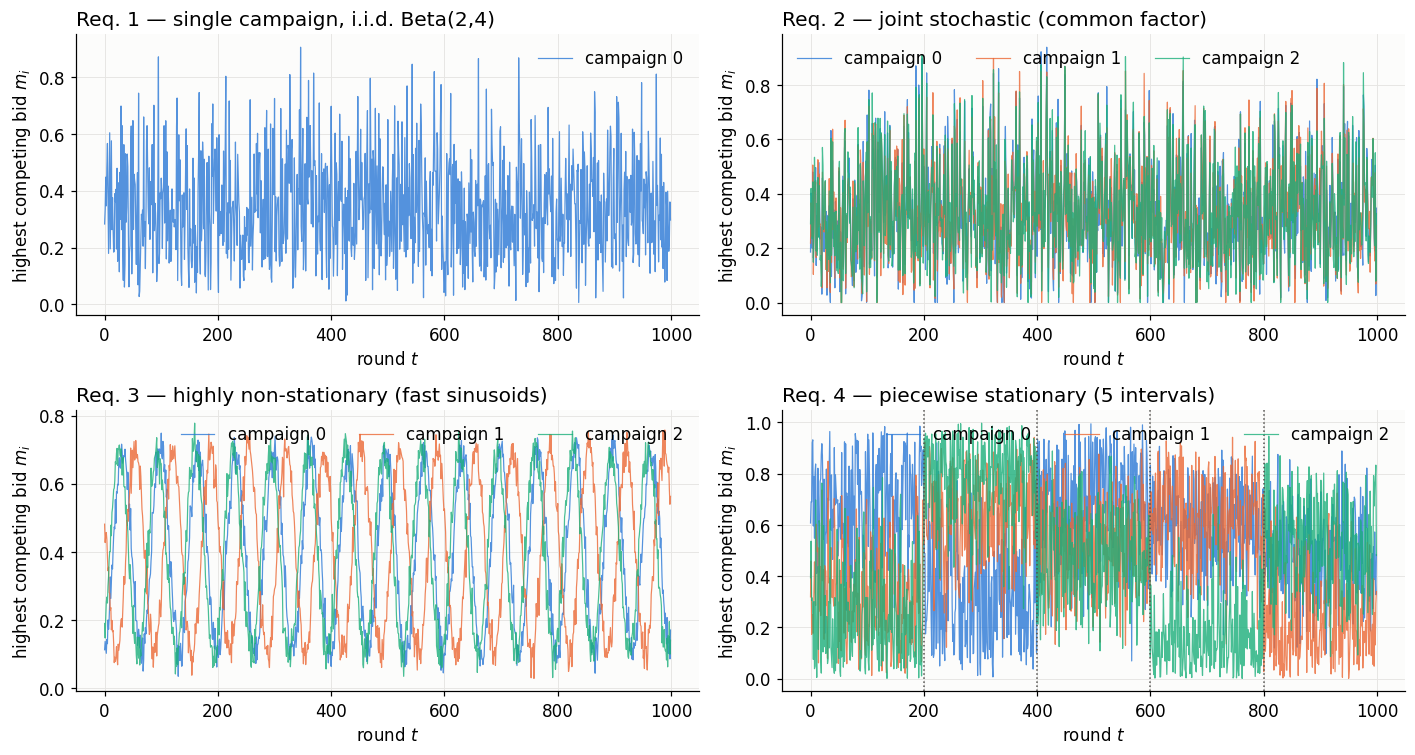

In [11]:
use_style()
VALUES3 = [0.9, 0.7, 0.8]
demo_envs = {
    "Req. 1 — single campaign, i.i.d. Beta(2,4)":
        SingleCampaignStochastic(T, value=0.8, seed=42),
    "Req. 2 — joint stochastic (common factor)":
        JointStochastic(3, T, VALUES3, seed=42),
    "Req. 3 — highly non-stationary (fast sinusoids)":
        HighlyNonStationary(3, T, VALUES3, seed=42),
    "Req. 4 — piecewise stationary (5 intervals)":
        PiecewiseStationary(3, T, VALUES3, n_intervals=5, seed=42),
}
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, (title, e) in zip(axes.flat, demo_envs.items()):
    plot_environment(e, title=title, ax=ax)
fig.tight_layout()

## 0.8 Clairvoyant demo + the curve to beat

Random agent on the Req. 2 environment: budget burnt early, then linear
regret. Every algorithm below must do better.

clairvoyant: utility/round 0.394, spend/round 0.150 (rho=0.15)
  p=0.508  c0: bid 0.2, c2: bid 0.2
  p=0.492  c0: bid 0.3, c2: bid 0.2


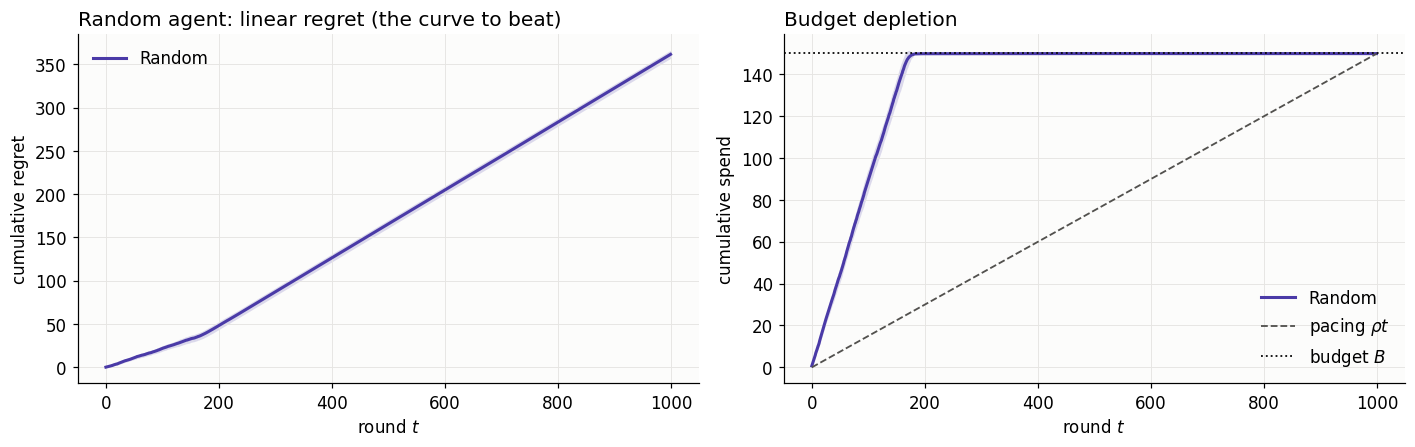

In [12]:
g3 = ConflictGraph(3, edges=[(0, 1)])   # campaigns 0 and 1 conflict
B_total = 150.0
rho = B_total / T

sol = clairvoyant_lp(JointStochastic(3, T, VALUES3, seed=7), g3, BIDS, rho=rho)
print(f"clairvoyant: utility/round {sol['value']:.3f}, spend/round {sol['cost']:.3f} (rho={rho})")
for arm, p in sorted(sol["policy"], key=lambda ap: -ap[1]):
    print(f"  p={p:.3f}  " + (", ".join(f"c{i}: bid {b:.1f}" for i, b in arm) or "(no bid)"))

def env_factory(seed):
    return JointStochastic(3, T, VALUES3, seed=seed)

res_rand = run_experiment(
    lambda rng: RandomAgent(3, VALUES3, BIDS, B_total, T, graph=g3, rng=rng),
    env_factory, n_trials=20)
baseline = clairvoyant_series(env_factory(0), g3, BIDS, rho=rho)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))
plot_regret({"Random": res_rand}, baseline,
            title="Random agent: linear regret (the curve to beat)", ax=ax1)
plot_spend({"Random": res_rand}, B_total, T, ax=ax2)
fig.tight_layout()

---
# 1. Requirement 1 — single campaign, stochastic (Person 2)

**Env:** `SingleCampaignStochastic`. **Algorithms:**
1. `UCB1` ignoring the budget — each bid is an arm, reward $(v-b)\,\mathbb{1}[b \ge m]$.
2. `UCBBudget` — UCB on utility, LCB on cost, per round solve the small LP
   over bid distributions with constraint $\le$ `self.pacing_rate`; matches the
   UCB-BwK scheme from practical session 08.

Deliver: regret plot vs clairvoyant (budget slack & binding), spend plot.

In [13]:
class UCB1(Agent):
    # TODO (Person 2)
    pass

class UCBBudget(Agent):
    # TODO (Person 2)
    pass

---
# 2. Requirement 2 — multiple campaigns, stochastic (Person 3)

**Env:** `JointStochastic` + conflict graph. **Algorithm:** `CUCBBudget` —
per-(campaign, bid) UCB utility / LCB cost, oracle =
`graph.max_weight_independent_set` on the per-campaign best UCB values,
joint pacing $\sum$ LCB-cost $\le \rho_t$.

Deliver: regret vs clairvoyant, per-campaign win rates, show the graph used.

In [14]:
class CUCBBudget(Agent):
    # TODO (Person 3)
    pass

---
# 3. Requirement 3 — best-of-both-worlds primal-dual (Person 4)

**Envs:** `JointStochastic` AND `HighlyNonStationary`, both with
`full_feedback=True`. **Algorithm:** `PrimalDual` —
dual: $\lambda_{t+1} = \Pi_{[0, 1/\rho]}(\lambda_t - \eta(\rho - \text{spend}_t))$;
primal: Hedge over super-arms on full-information Lagrangian payoffs
$\sum_i (v_i - b_i)\mathbb{1}[b_i \ge m_i] - \lambda_t b_i \mathbb{1}[b_i \ge m_i]$.

Deliver: both envs × {CUCBBudget, PrimalDual} regret, plus the $\lambda_t$
trajectory (pacing emerges automatically — nice slide).

In [15]:
class PrimalDual(Agent):
    # TODO (Person 4)
    pass

---
# 4. Requirement 4 — slightly non-stationary (Person 5)

**Env:** `PiecewiseStationary`. **Algorithms:** `SWCUCB` (sliding window
$W \approx \sqrt{TK}$), `CDCUCB` (CUSUM-style change detector, reset stats on
detection), and `PrimalDual` from Section 3 run as-is.

Deliver (explicitly required): 3-way comparison on the same trials vs the
per-interval clairvoyant. Discuss surprises — the professor appreciates
honest discussion of unexpected results.

In [16]:
class SWCUCB(Agent):
    # TODO (Person 5)
    pass

class CDCUCB(Agent):
    # TODO (Person 5)
    pass

---
# Deliverable checklist

- [ ] Slides: high-level algorithm descriptions + empirical graphs
- [ ] GitHub repo link
- [ ] 20-min presentation + 10-min Q&A, dry-run once as a group
- Target: everything done by **24 August** (September session)